# 02 — Analyse des erreurs de classification

KOMOSSI Sosso — Master BIG DATA IA, Institut ESI — UCAO-UUT, 2025-2026

Ce notebook charge par défaut les résultats déjà produits par `scripts/generate_reports.py` (`reports/metrics_summary.json`, `reports/RAPPORT_ANALYSE.md`, `reports/figures/`) — aucune ré-inférence n'est nécessaire pour le lire. La dernière section (optionnelle, désactivée par défaut) permet de rejouer l'inférence sur le jeu de test complet si l'on souhaite vérifier les chiffres soi-même (~15-20 minutes CPU sur la machine de référence, 14 Go de RAM — voir README.md).

In [1]:
import json, os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
with open(os.path.join(ROOT, 'reports/metrics_summary.json')) as f:
    metrics = json.load(f)
metrics

{'best_epoch': 3,
 'val_f1_best': 0.9392,
 'test_f1_macro': 0.9369934649773259,
 'test_precision': 0.9386859429456564,
 'test_recall': 0.935064935064935,
 'test_roc_auc': 0.9899293966943307,
 'test_average_precision': 0.9899788418143135,
 'confusion_matrix': {'tn': 7302, 'fp': 475, 'fn': 505, 'tp': 7272},
 'n_test_examples': 15554,
 'per_source_accuracy': {'welfake': 0.9772,
  'fakenewsnet': 0.9757,
  'liar': 0.6197,
  'masakhanews_hau': 1.0,
  'masakhanews_swa': 1.0,
  'masakhanews_yor': 1.0,
  'masakhanews_sna': 0.9951,
  'masakhanews_amh': 1.0,
  'masakhanews_ibo': 1.0,
  'masakhanews_orm': 0.9936,
  'masakhanews_pcm': 0.993,
  'masakhanews_run': 1.0,
  'masakhanews_som': 1.0,
  'masakhanews_tir': 1.0,
  'masakhanews_lin': 1.0,
  'google_news_africa_rss': 1.0},
 'per_source_f1_two_classes_only': {'welfake': 0.9757,
  'fakenewsnet': 0.9744,
  'liar': 0.5977}}

## Métriques globales (jeu de test, 15 554 exemples tenus à l'écart)

In [2]:
cm = metrics['confusion_matrix']
print(f"F1-macro       : {metrics['test_f1_macro']:.4f}")
print(f"Précision      : {metrics['test_precision']:.4f}")
print(f"Rappel         : {metrics['test_recall']:.4f}")
print(f"AUC-ROC        : {metrics['test_roc_auc']:.4f}")
print(f"Average Prec.  : {metrics['test_average_precision']:.4f}")
print(f"Matrice        : TP={cm['tp']} TN={cm['tn']} FP={cm['fp']} FN={cm['fn']}")
fp_rate = cm['fp'] / (cm['fp'] + cm['tn'])
print(f"Taux de faux positifs (réel classé fake à tort) : {fp_rate:.2%} "
      '— le risque opérationnel le plus sensible du projet (accusation infondée).')

F1-macro       : 0.9370
Précision      : 0.9387
Rappel         : 0.9351
AUC-ROC        : 0.9899
Average Prec.  : 0.9900
Matrice        : TP=7272 TN=7302 FP=475 FN=505
Taux de faux positifs (réel classé fake à tort) : 6.11% — le risque opérationnel le plus sensible du projet (accusation infondée).


## Performance par source

Les sources mono-classe (sous-corpus africains, exclusivement réels) ont une exactitude apparente de 1,00 sans valeur discriminante — elles sont grisées sur la figure. Seules welfake, fakenewsnet et liar contiennent les deux classes.

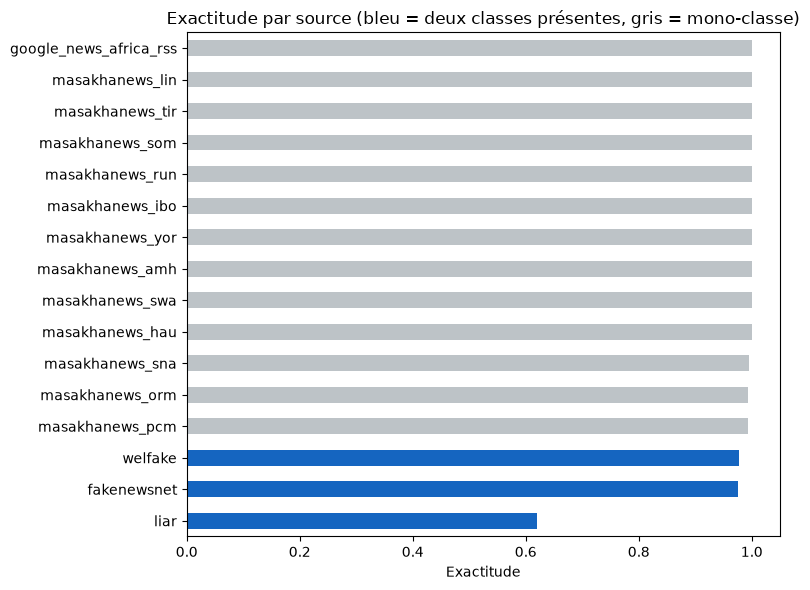

liar           0.5977
fakenewsnet    0.9744
welfake        0.9757
dtype: float64

In [3]:
acc = pd.Series(metrics['per_source_accuracy']).sort_values()
two_class = set(metrics['per_source_f1_two_classes_only'].keys())
colors = ['#1565C0' if s in two_class else '#BDC3C7' for s in acc.index]
fig, ax = plt.subplots(figsize=(8, 6))
acc.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Exactitude'); ax.set_xlim(0, 1.05)
ax.set_title('Exactitude par source (bleu = deux classes présentes, gris = mono-classe)')
plt.tight_layout(); plt.show()
pd.Series(metrics['per_source_f1_two_classes_only']).sort_values()

**Lecture** : le modèle est quasi parfait sur WELFake/FakeNewsNet (registre journalistique anglophone, marqueurs stylistiques nets) mais chute nettement sur LIAR (F1 ≈ 0,60) — des déclarations politiques courtes, sans les marqueurs stylistiques propres aux articles fabriqués. C'est précisément ce terrain faible qui est exploité dans l'expérience « dérive = opportunité » (`scripts/experiment_derive_opportunite.py`, `reports/EXPERIENCES_2026-08-29.md`).

## Figures déjà générées (`reports/figures/`)

Matrice de confusion, courbes ROC/PR, calibration, distribution de confiance — produites par `scripts/generate_reports.py` sur le même jeu de test.

01_courbes_apprentissage.png


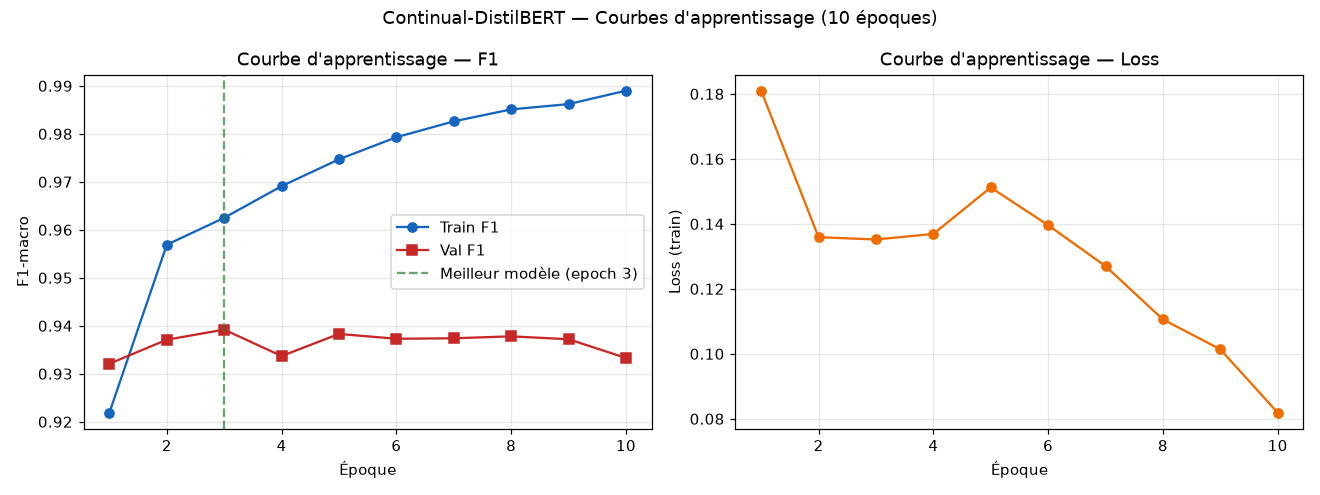

02_matrice_confusion.png


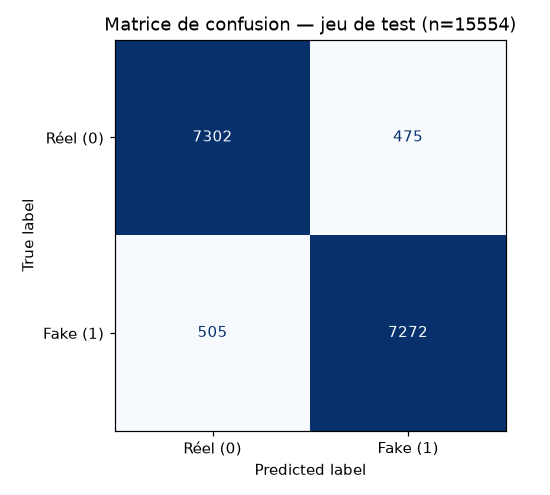

03_courbe_roc.png


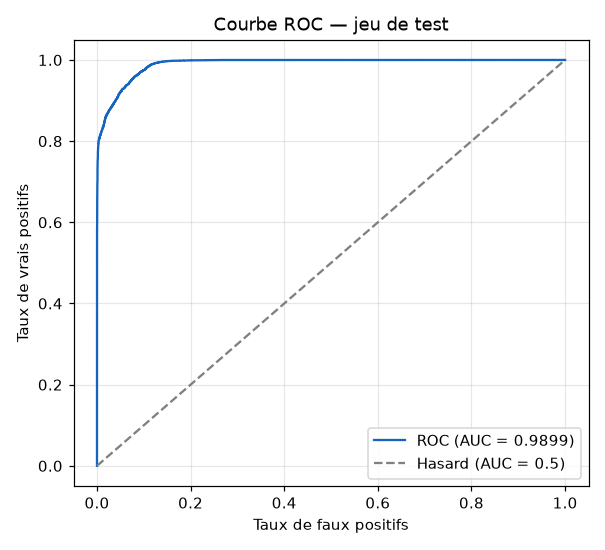

04_courbe_precision_rappel.png


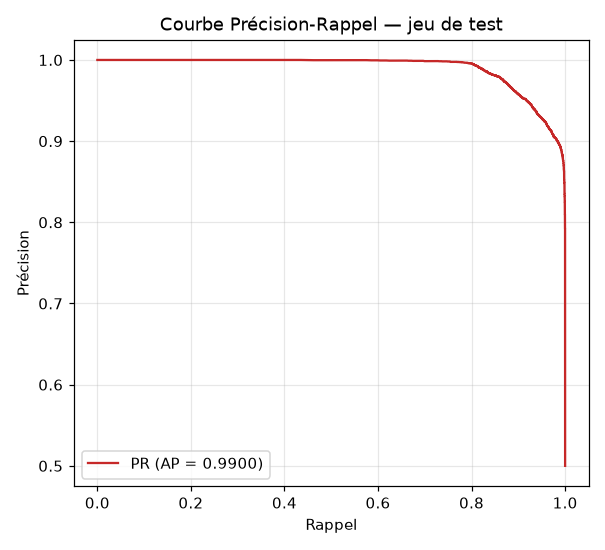

05_repartition_corpus.png


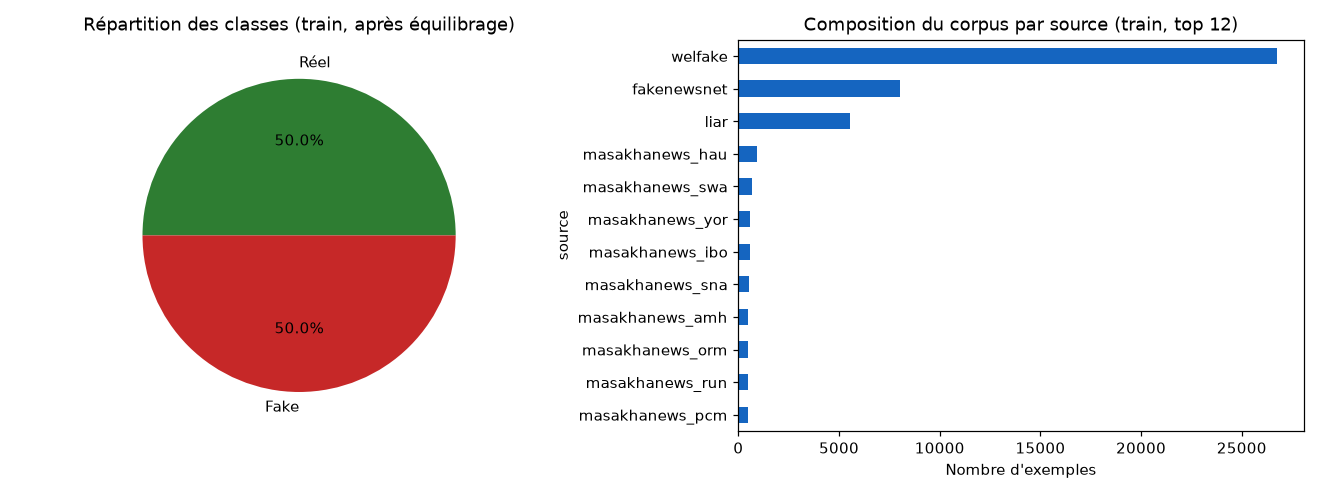

06_performance_par_source.png


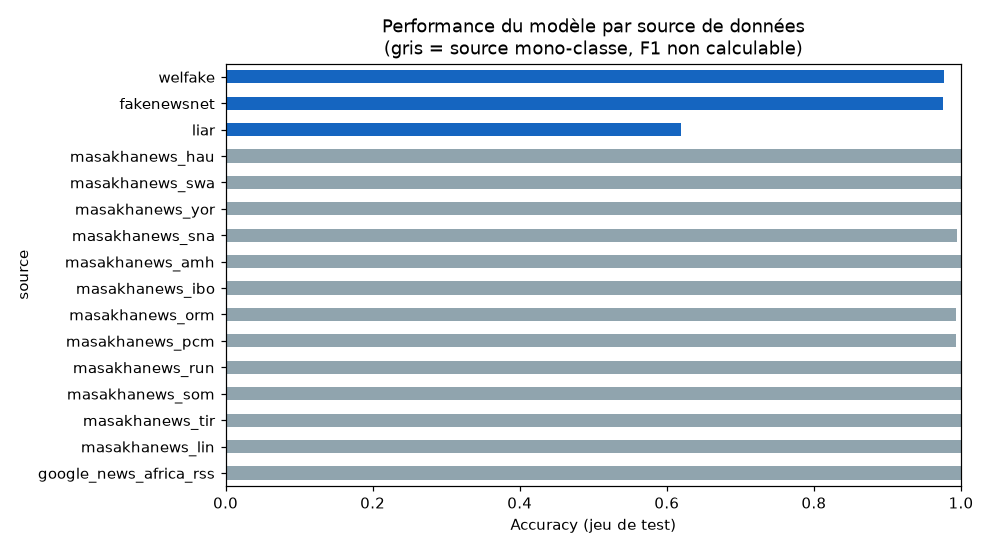

07_matrice_correlation.png


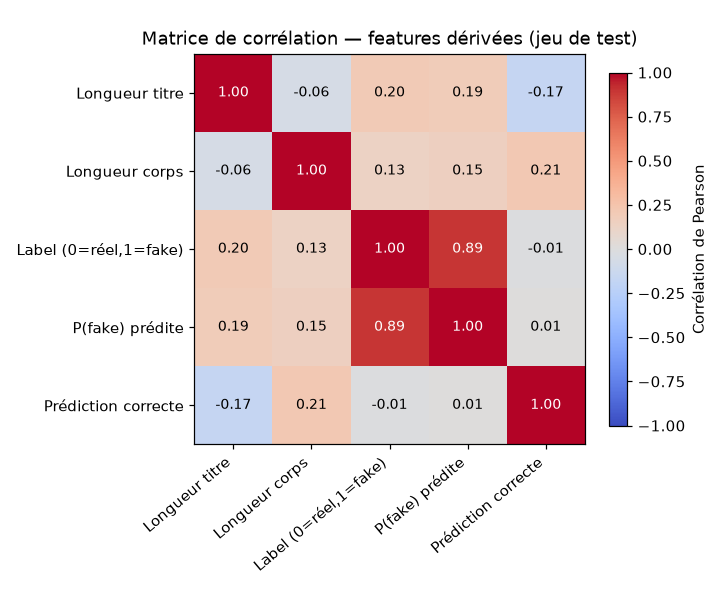

08_distribution_confiance.png


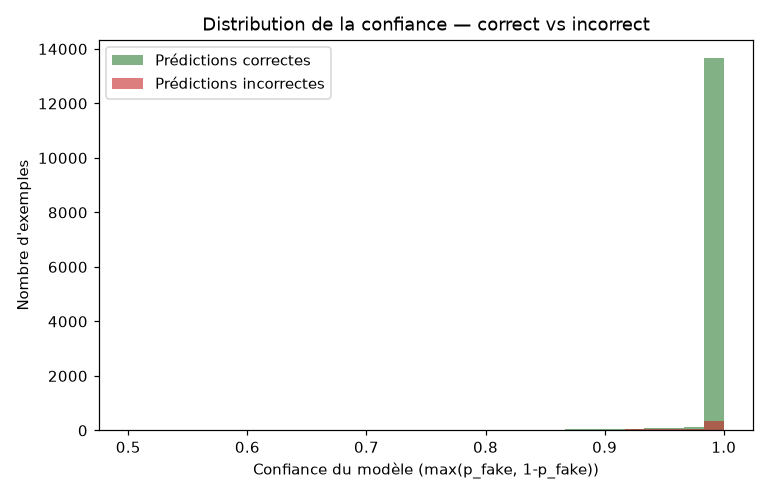

09_tri_detecteur_scenarios.png


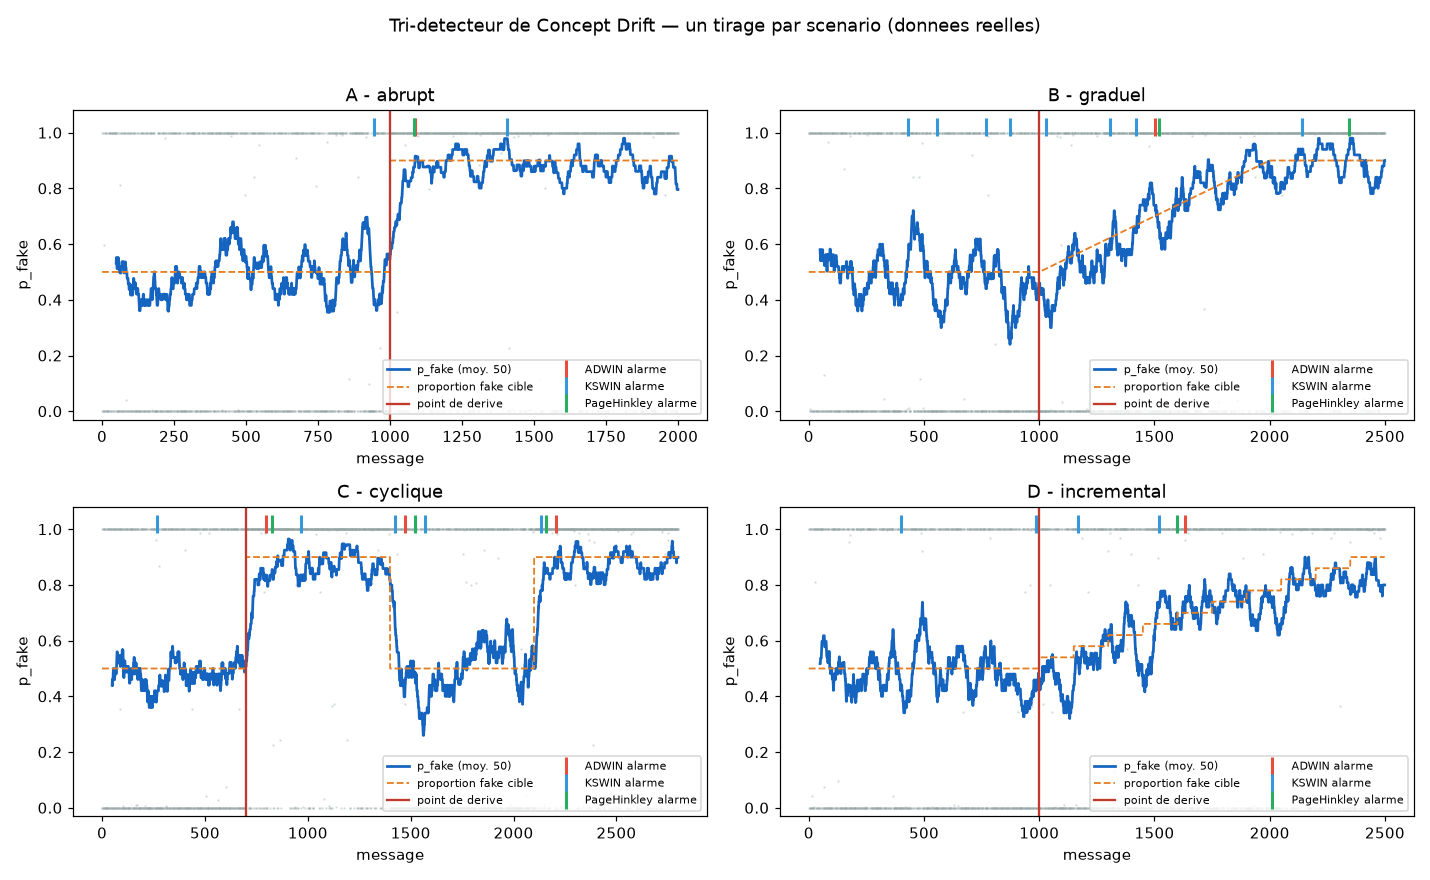

In [4]:
import glob
figs = sorted(glob.glob(os.path.join(ROOT, 'reports/figures/0*.png')))
for fp in figs:
    print(os.path.basename(fp))
    display(Image(filename=fp, width=650))

## (Optionnel) Rejouer l'inférence et inspecter des exemples mal classés

Désactivé par défaut (`RUN_INFERENCE = False`) — nécessite `models/pretrained/` (non versionné, voir `scripts/train_model.py`) et prend plusieurs minutes en CPU.

In [5]:
RUN_INFERENCE = False

if RUN_INFERENCE:
    import torch
    from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
    tok = DistilBertTokenizerFast.from_pretrained(os.path.join(ROOT, 'models/pretrained'))
    mdl = DistilBertForSequenceClassification.from_pretrained(
        os.path.join(ROOT, 'models/pretrained')).cpu().eval()
    test = pd.read_csv(os.path.join(ROOT, 'data/processed/test/test.csv'))
    texts = [f"{str(t)[:200]} [SEP] {str(b)[:100]}" for t, b in zip(test.title, test.body)]
    preds = []
    for i in range(0, len(texts), 64):
        enc = tok(texts[i:i+64], max_length=128, padding='max_length',
                  truncation=True, return_tensors='pt')
        with torch.no_grad():
            p = torch.softmax(mdl(**enc).logits, -1)[:, 1].numpy()
        preds.extend(p.tolist())
    test['p_fake'] = preds
    test['pred'] = (test.p_fake >= 0.5).astype(int)
    errors = test[test.pred != test.label]
    print(f'{len(errors)} erreurs sur {len(test)} exemples')
    display(errors[['source', 'title', 'label', 'p_fake']].sample(min(10, len(errors))))
else:
    print('RUN_INFERENCE=False — passez à True pour rejouer l\'inférence (~15-20 min CPU).')

RUN_INFERENCE=False — passez à True pour rejouer l'inférence (~15-20 min CPU).
